In [6]:
import os, glob

In [8]:
glob.glob('core.[0-9]*')

['core.46978']

# XML Description

In [8]:
!pip install pydantic-xml[lxml]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 6.6 MB/s eta 0:00:004 MB/s eta 0:00:01:01


In [18]:
import pathlib

In [34]:
%%writefile scripts/xmlDescription.py
# Genterated automatically by /run.ipynb
from pydantic_xml import BaseXmlModel, attr, element
from pydantic import Field
from typing import Optional, Union, List, Literal

class IDModel(BaseXmlModel):
    id: str = attr()
class IO(IDModel):
    description: Optional[str] = None
    width_description: Optional[str] = attr(default=None)
class Ports(BaseXmlModel, tag="ports"):
    input: List[IO] = element()
    output: List[IO] = element()

class Parameter(IDModel):
    description: Optional[str] = None
class ParameterDescription(BaseXmlModel, tag="parameter_description"):
    parameter: List[Parameter] = element()

class PartialLogicDescription(IDModel):
    description: Optional[str] = None
    width_description: Optional[str] = attr(default=None)
    type: Literal["combinational_logic", "combinational_logic_operation", "sequential_logic", "sequential_logic_operation"] = attr()
    
class LogicDescription(BaseXmlModel, tag="logic_description", search_mode='unordered'):
    description: str = element()
    logic: List[PartialLogicDescription] = element(default=None)
    
class Module(IDModel, tag='module'):
    description: str = element(default=None)
    ports: Optional[Ports] = element(default=None)
    parameter_description: Optional[ParameterDescription] = element(default=None)
    logic_description: Optional[LogicDescription] = element(default=None)
    implementation: str = element()
    task: str = element(default="Give me the complete Verilog code.")

Overwriting scripts/xmlDescription.py


In [35]:
%run scripts/xmlDescription.py

In [37]:
xml_doc = pathlib.Path('./test/test.xml').read_text()
xml_doc
xml_module = Module.from_xml(xml_doc)
xml_module

Module(id='div_8bit', description='Implement a simplified radix-2 divider on 8-bit signed or unsigned integers. and the inputs are two 8-bit operands. The module accepts a dividend and a divisor as inputs and provides a 16-bit result containing both the quotient and the remainder. The design supports both signed and unsigned division operations.', ports=Ports(input=[IO(id='clk', description='Clock signal used for synchronous operation.', width_description=None), IO(id='rst', description='The reset signal to initialize or reset the module.', width_description=None), IO(id='sign', description='1-bit indicates if the operation is signed (1) or unsigned (0).', width_description=None), IO(id='dividend', description='8-bit input signal representing the dividend for division.', width_description=None), IO(id='divisor', description='8-bit input signal representing the divisor for division.', width_description=None), IO(id='opn_valid', description='1-bit indicates that a valid operation request

In [38]:
json_doc = pathlib.Path('./test/export.xml')
json_doc.write_text(xml_module.to_xml(pretty_print=True).decode('utf-8'))
# xml_module.to_xml(encoding='utf-8').decode('utf-8')
# json_doc.write_text(xml_module.to_xml().decode('utf-8'))

9305

In [40]:
json_doc = pathlib.Path('./test/test.json')
json_doc.write_text(xml_module.model_dump_json(indent=4))

1969

In [ ]:
# from_json?


# Hashlib

# Code Agent

In [2]:
%%writefile scripts/codeAgent.py
class LLMCodeAgent:
    def __init__(self, modulePath:str):
        pass
    def __iter__(self):
        self.a = 1
        self.status = "error"
        return self
    def __next__(self):
        confirm = input(f"Next? (y/n) ")
        if confirm == "n" or confirm == "N":
            print("End Agent")
            raise StopIteration

        x = self.a
        self.a += 1
        return (x, self.status)

    def __call__(self):
        print("Start agent")
        myiter = iter(self)
        currentStatus = None
        for x in myiter:
            currentStatus = x
            print("iter status", currentStatus[1], ". iter times: ", currentStatus[0])

        print("last status", currentStatus[1], ". iter times: ", currentStatus[0])


Overwriting scripts/codeAgent.py


In [ ]:
import os
os._exit(00)

In [5]:
%run scripts/codeAgent.py

In [6]:
from scripts.codeAgent import LLMCodeAgent

llmCodeAgent = LLMCodeAgent('modules/adder_8bit')

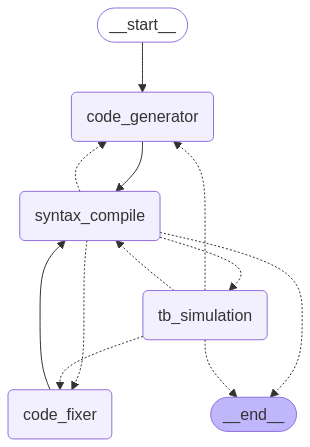

In [7]:
llmCodeAgent.pnggraph()

In [21]:
import json
jsontxt = """Warns that inside a case statement, there is a stimulus pattern for which no case item is provided. This is bad style; if a case is impossible, it’s better to have a `default: ;` so that any design assumption violations will be discovered in the simulation.
In the `default` case, all bits of all driven signals should be assigned to the `x` state.
"""
a = {'txt': jsontxt}
json.dump(a, open('.ignore/tmp.txt', 'w+'))

In [13]:
import json
jsontxt = """A Warning that the specified signal is never used/consumed.
For example, you have a wire called `a`, declared as follows:

```sv
wire [3:0] a;
```

But in the operation of a module, you only use 2/4 bits of the wire `a`. For example:

```sv
assign a[1:0] = {1'b0, 1'b1};
```

And you forgot to use the `a[3:2]`. So, that is why this warning is raised.

You should fix this warning by removing unused signals in the declaration of a port, such as:

```sv
wire [1:0] a;
```

Or you can make use of the unused signals that you forgot:

```sv
assign a[3:0] = {1'b0, 1'b1, 1'b0, 1'b1};
```

"""
a = {'txt': jsontxt}
json.dump(a, open('.ignore/tmp.txt', 'w+'))

In [25]:
import ast
from scripts.lazy import readFileContent

verilator_warns = readFileContent("rag/verilator_warns.json")
verilator_warns: dict = ast.literal_eval(verilator_warns)

print(verilator_warns["WIDTHEXPAND"])

A more granular `WIDTH` warning, for
when a value is zero expanded.

Here is the description of `WIDTH` warning:

Warns that based on the width rules of Verilog:

-   Two operands have different widths, e.g., adding a 2-bit and 5-bit
    number.
-   A part select has a different size then needed to index into the
    packed or unpacked array, etc.

Verilator attempts to track the minimum width of unsized constants and
will suppress the warning when the minimum width is appropriate to fit
the required size.

Ignoring this warning will only suppress the lint check; it will
simulate correctly.

The recommendation is to fix these issues by:

-   Resize the variable or constant to match the needed size for the
    expression. E.g., `2'd2` instead of `3'd2`.
-   Using `'0` or `'1`, which automatically resize in an expression.
-   Using part selects to narrow a variable; e.g., `too_wide[1:0]`.
-   Using concatenate to widen a variable; e.g., `{1'b1, too_narrow}`.
-   Using cast to resize a va

# VCD Parser

In [1]:
!pip install vcdvcd

In [2]:
from vcdvcd import VCDVCD

In [3]:

# Do the parsing.
vcd = VCDVCD('waveform.vcd')

# List all human readable signal names.
print(vcd.references_to_ids.keys())

dict_keys(['TOP.rst_n', 'TOP.clk', 'TOP.pass_request', 'TOP.clock[7:0]', 'TOP.red', 'TOP.yellow', 'TOP.green', 'TOP.traffic_light.rst_n', 'TOP.traffic_light.clk', 'TOP.traffic_light.pass_request', 'TOP.traffic_light.clock[7:0]', 'TOP.traffic_light.red', 'TOP.traffic_light.yellow', 'TOP.traffic_light.green', 'TOP.traffic_light.idle[1:0]', 'TOP.traffic_light.s1_red[1:0]', 'TOP.traffic_light.s2_yellow[1:0]', 'TOP.traffic_light.s3_green[1:0]', 'TOP.traffic_light.cnt[7:0]', 'TOP.traffic_light.state[1:0]', 'TOP.traffic_light.p_red', 'TOP.traffic_light.p_yellow', 'TOP.traffic_light.p_green'])


In [4]:
# View all signal data.
print(vcd.data)

{'(': {'endtime': 299,
 'references': ['TOP.rst_n', 'TOP.traffic_light.rst_n'],
 'size': '1',
 'tv': [(0, '0'), (8, '1')],
 'var_type': 'wire'}, ')': {'endtime': 299,
 'references': ['TOP.clk', 'TOP.traffic_light.clk'],
 'size': '1',
 'tv': [(0, '1'),
        (1, '0'),
        (2, '1'),
        (3, '0'),
        (4, '1'),
        (5, '0'),
        (6, '1'),
        (7, '0'),
        (8, '1'),
        (9, '0'),
        (10, '1'),
        (11, '0'),
        (12, '1'),
        (13, '0'),
        (14, '1'),
        (15, '0'),
        (16, '1'),
        (17, '0'),
        (18, '1'),
        (19, '0'),
        (20, '1'),
        (21, '0'),
        (22, '1'),
        (23, '0'),
        (24, '1'),
        (25, '0'),
        (26, '1'),
        (27, '0'),
        (28, '1'),
        (29, '0'),
        (30, '1'),
        (31, '0'),
        (32, '1'),
        (33, '0'),
        (34, '1'),
        (35, '0'),
        (36, '1'),
        (37, '0'),
        (38, '1'),
        (39, '0'),
        (40, '1'